In [1]:
ML_DATA_PATH = './data/ml_data.csv'
ML_DATA_TRAIN_PATH = './data/ml_data_train.csv'
ML_DATA_VAL_PATH = './data/ml_data_val.csv'
ML_DATA_TEST_PATH = './data/ml_data_test.csv'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
data = pd.read_csv(ML_DATA_PATH, index_col=0)
data['board'] = data['board'].apply(json.loads)
data

,board,white_king_rights,white_queen_rights,black_king_rights,black_queen_rights,initial_pos,final_pos
0,"[[[-1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, -1.0,...",1,1,1,1,e2,e4
1,"[[[-1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, -1.0,...",1,1,1,1,g1,f3
2,"[[[-1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, -1.0,...",1,1,1,1,d2,d4
3,"[[[-1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, -1.0,...",1,1,1,1,b2,b3
4,"[[[-1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, -1.0,...",1,1,1,1,f1,d3
...,...,...,...,...,...,...,...
34457,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0...",0,0,0,0,f4,e5
34458,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0...",0,0,0,0,c1,c6
34459,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0...",0,0,0,0,e5,d6
34460,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0...",0,0,0,0,d6,d8


In [3]:
train_df, test_df = train_test_split(data, test_size=0.1, shuffle=True, random_state=47)
train_gen = ImageDataGenerator(validation_split=0.15)
test_gen = ImageDataGenerator()

In [4]:
def create_model(input_shape):
    inputs = Input(shape=input_shape)

    x1 = Conv2D(8, (3, 3), padding='same', activation='relu')(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.2)(x1)
    
    x2 = Conv2D(32, (3, 3), padding='same', activation='relu')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.2)(x2)
    
    x3 = Conv2D(64, (3, 3), padding='same', activation='relu')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.2)(x3)

    xtop = Flatten()(x3)
    xtop = Dense(256, activation='relu')(xtop)
    xtop = Dropout(0.2)(xtop)
    xtop = Dense(128, activation='relu')(xtop)
    xtop = Dropout(0.2)(xtop)

    predictions = Dense(64, activation='softmax')(xtop)

    model = Model(inputs=inputs, outputs=predictions)
    return model


In [5]:
INPUT_SHAPE = (8, 8, 6)
model = create_model(INPUT_SHAPE)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 8, 8, 6)]         0         
                                                                 
 conv2d (Conv2D)             (None, 8, 8, 8)           440       
                                                                 
 batch_normalization (BatchN  (None, 8, 8, 8)          32        
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 8, 8, 8)           0         
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 32)          2336      
                                                                 
 batch_normalization_1 (Batc  (None, 8, 8, 32)         128       
 hNormalization)                                             

In [6]:
X = np.array(train_df['board'].tolist())
Y = np.array(train_df['initial_pos'].tolist())

In [7]:
num_classes = len(np.unique(Y))
num_classes

64

In [8]:
unique_labels = train_df['initial_pos'].unique()
label_encoder = LabelEncoder()
a = label_encoder.fit_transform(train_df['initial_pos'])

In [9]:
catY = keras.utils.to_categorical(a, num_classes=num_classes)
catY.shape

(31015, 64)

In [10]:
X.shape

(31015, 8, 8, 6)

In [11]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
history = model.fit(x = X, y = catY, batch_size=32, epochs=10, validation_split=0.15)

Epoch 1/10
824/824 [==============================] - 7s 5ms/step - loss: 3.5416 - accuracy: 0.1150 - val_loss: 3.1669 - val_accuracy: 0.2037
Epoch 2/10
824/824 [==============================] - 4s 5ms/step - loss: 3.1216 - accuracy: 0.2065 - val_loss: 2.7426 - val_accuracy: 0.2768
Epoch 3/10
824/824 [==============================] - 4s 5ms/step - loss: 2.8020 - accuracy: 0.2627 - val_loss: 2.5146 - val_accuracy: 0.3065
Epoch 4/10
824/824 [==============================] - 4s 5ms/step - loss: 2.6017 - accuracy: 0.2963 - val_loss: 2.3874 - val_accuracy: 0.3312
Epoch 5/10
824/824 [==============================] - 4s 5ms/step - loss: 2.4614 - accuracy: 0.3171 - val_loss: 2.2827 - val_accuracy: 0.3445
Epoch 6/10
824/824 [==============================] - 4s 5ms/step - loss: 2.3474 - accuracy: 0.3373 - val_loss: 2.2481 - val_accuracy: 0.3419
Epoch 7/10
824/824 [==============================] - 4s 5ms/step - loss: 2.2601 - accuracy: 0.3505 - val_loss: 2.1942 - val_accuracy: 0.3486
Epoch 

In [15]:
def plot_graph(history):
  df = pd.DataFrame(history.history)

  plt.style.use('fast')
  plt.figure(figsize=(25,8))

  plt.subplot(1,2,1)
  plt.title("Loss Curve")
  plt.plot(df['loss'], label="Loss")
  plt.plot(df['val_loss'], label="Val Loss")
  plt.xlabel("Epochs")
  plt.legend(fontsize=15)
  plt.ylabel("Loss")

  plt.subplot(1,2,2)
  plt.title("Accuracy Curve")
  plt.plot(df['accuracy'], label="Accuracy")
  plt.plot(df['val_accuracy'], label="Val Accuracy")
  plt.xlabel("Epochs")
  plt.legend(fontsize=15)
  plt.ylabel("Accuracy")

  plt.show()

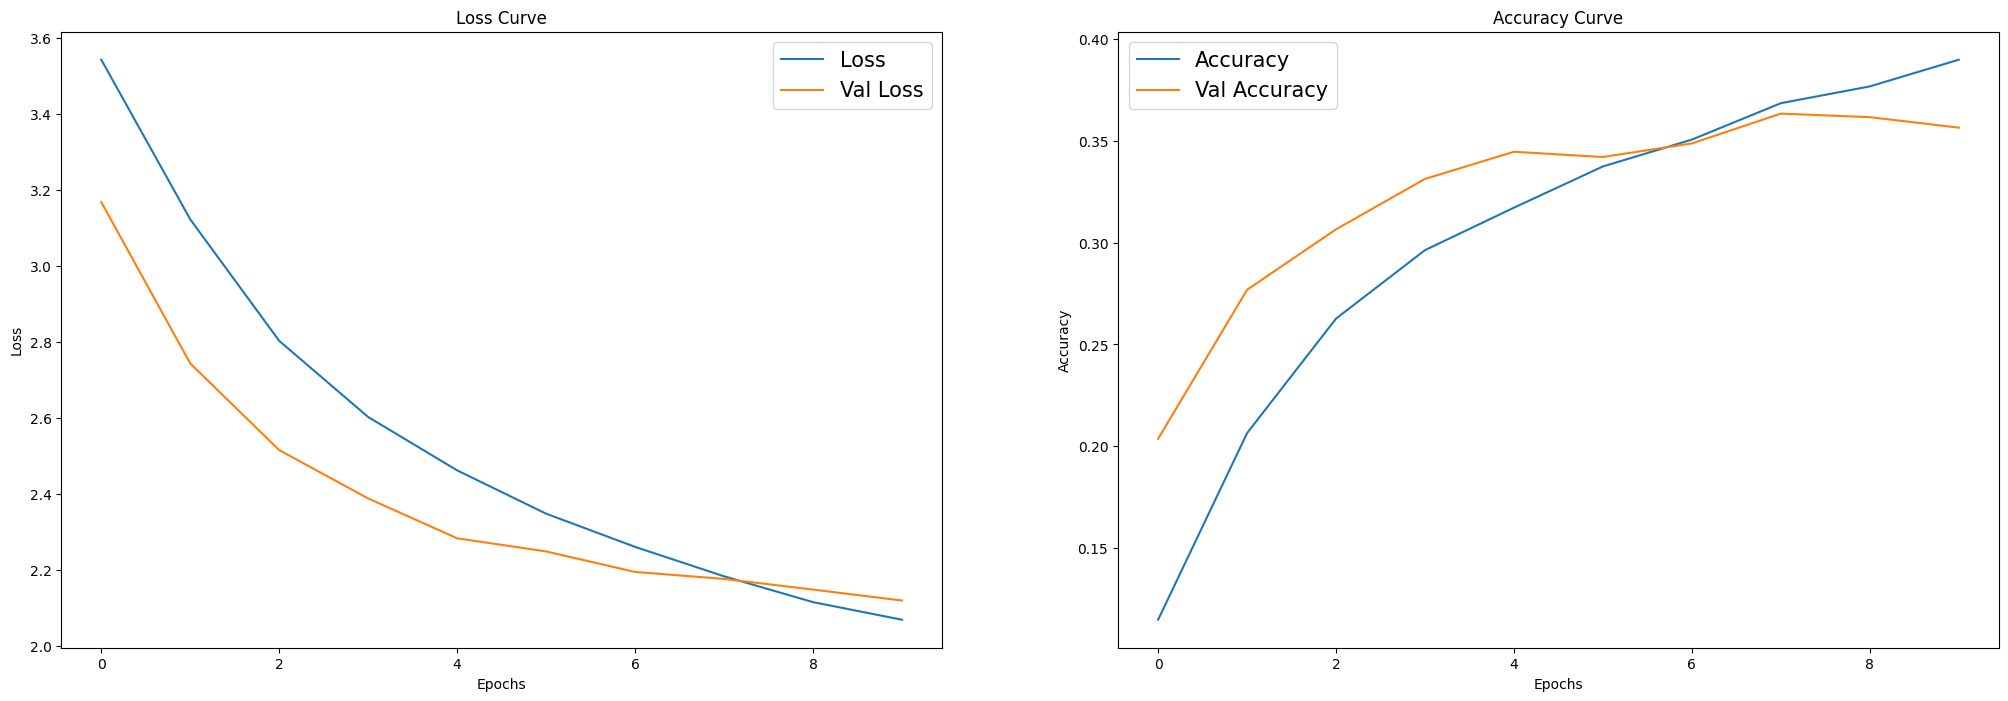

In [16]:
plot_graph(history=history)

# Con DataGenerator

In [267]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_path, read_size, batch_size, num_classes, csv_length):
        self.file_path = file_path
        self.batch_size = batch_size
        self.read_size = read_size
        self.num_classes = num_classes
        self.csv_length = csv_length
        self.current_read = None
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.csv_length / self.batch_size))

    def on_epoch_end(self):
        pass

    def __getitem__(self, index):
        if index % (self.read_size // self.batch_size) == 0:
            self.current_read = pd.read_csv(self.file_path, skiprows=range(1, (index * self.batch_size) + 1), nrows=self.read_size)
        batch = self.get_batch(index % (self.read_size // self.batch_size))
        X, y = self.__data_generation__(batch)
        return X, y

    def __data_generation__(self, df):
        X = np.array(df['board'].apply(json.loads).tolist())
        y = self.encode_pos(df['initial_pos'])
        return X, y
    
    def get_batch(self, index):
        start = index * self.batch_size
        end = start + self.batch_size
        return self.current_read.iloc[start:end]

    def encode_pos(self, positions):
        column_to_number = {
            'a': 1,
            'b': 2,
            'c': 3,
            'd': 4,
            'e': 5,
            'f': 6,
            'g': 7,
            'h': 8
        }
        encoded_positions = []
        for pos in positions:
            encoded_pos = np.zeros(64)
            encoded_pos[((column_to_number.get(pos[0]) - 1)) +  ((8 - int(pos[1])) * 8)] = 1
            encoded_positions.append(encoded_pos)
        return np.array(encoded_positions)


In [268]:
read_size = 256
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447)

In [269]:
def create_model(input_shape):
    inputs = Input(shape=input_shape)

    x1 = Conv2D(8, (3, 3), padding='same', activation='relu')(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.2)(x1)
    
    x2 = Conv2D(32, (3, 3), padding='same', activation='relu')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.2)(x2)
    
    x3 = Conv2D(64, (3, 3), padding='same', activation='relu')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.2)(x3)

    xtop = Flatten()(x3)
    xtop = Dense(256, activation='relu')(xtop)
    xtop = Dropout(0.2)(xtop)
    xtop = Dense(128, activation='relu')(xtop)
    xtop = Dropout(0.2)(xtop)

    predictions = Dense(64, activation='softmax')(xtop)

    model = Model(inputs=inputs, outputs=predictions)
    return model

In [270]:
INPUT_SHAPE = (8, 8, 6)
model = create_model(INPUT_SHAPE)
model.summary()

Model: "model_34"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_35 (InputLayer)       [(None, 8, 8, 6)]         0         
                                                                 
 conv2d_102 (Conv2D)         (None, 8, 8, 8)           440       
                                                                 
 batch_normalization_102 (Ba  (None, 8, 8, 8)          32        
 tchNormalization)                                               
                                                                 
 dropout_170 (Dropout)       (None, 8, 8, 8)           0         
                                                                 
 conv2d_103 (Conv2D)         (None, 8, 8, 32)          2336      
                                                                 
 batch_normalization_103 (Ba  (None, 8, 8, 32)         128       
 tchNormalization)                                        

In [271]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'],)

In [272]:
history = model.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False)

Epoch 1/20
873/873 [==============================] - 17s 19ms/step - loss: 3.5404 - accuracy: 0.1088 - val_loss: 3.1207 - val_accuracy: 0.1931
Epoch 2/20
873/873 [==============================] - 16s 18ms/step - loss: 3.0836 - accuracy: 0.2083 - val_loss: 2.6775 - val_accuracy: 0.2801
Epoch 3/20
873/873 [==============================] - 16s 18ms/step - loss: 2.7934 - accuracy: 0.2632 - val_loss: 2.4666 - val_accuracy: 0.3211
Epoch 4/20
873/873 [==============================] - 16s 19ms/step - loss: 2.6089 - accuracy: 0.2942 - val_loss: 2.3761 - val_accuracy: 0.3221
Epoch 5/20
873/873 [==============================] - 16s 19ms/step - loss: 2.4711 - accuracy: 0.3173 - val_loss: 2.2999 - val_accuracy: 0.3320
Epoch 6/20
873/873 [==============================] - 16s 19ms/step - loss: 2.3549 - accuracy: 0.3344 - val_loss: 2.2517 - val_accuracy: 0.3346
Epoch 7/20
873/873 [==============================] - 16s 19ms/step - loss: 2.2536 - accuracy: 0.3517 - val_loss: 2.1894 - val_accuracy:

In [273]:
def plot_graph(history):
  df = pd.DataFrame(history.history)

  plt.style.use('fast')
  plt.figure(figsize=(25,8))

  plt.subplot(1,2,1)
  plt.title("Loss Curve")
  plt.plot(df['loss'], label="Loss")
  plt.plot(df['val_loss'], label="Val Loss")
  plt.xlabel("Epochs")
  plt.legend(fontsize=15)
  plt.ylabel("Loss")

  plt.subplot(1,2,2)
  plt.title("Accuracy Curve")
  plt.plot(df['accuracy'], label="Accuracy")
  plt.plot(df['val_accuracy'], label="Val Accuracy")
  plt.xlabel("Epochs")
  plt.legend(fontsize=15)
  plt.ylabel("Accuracy")

  plt.show()

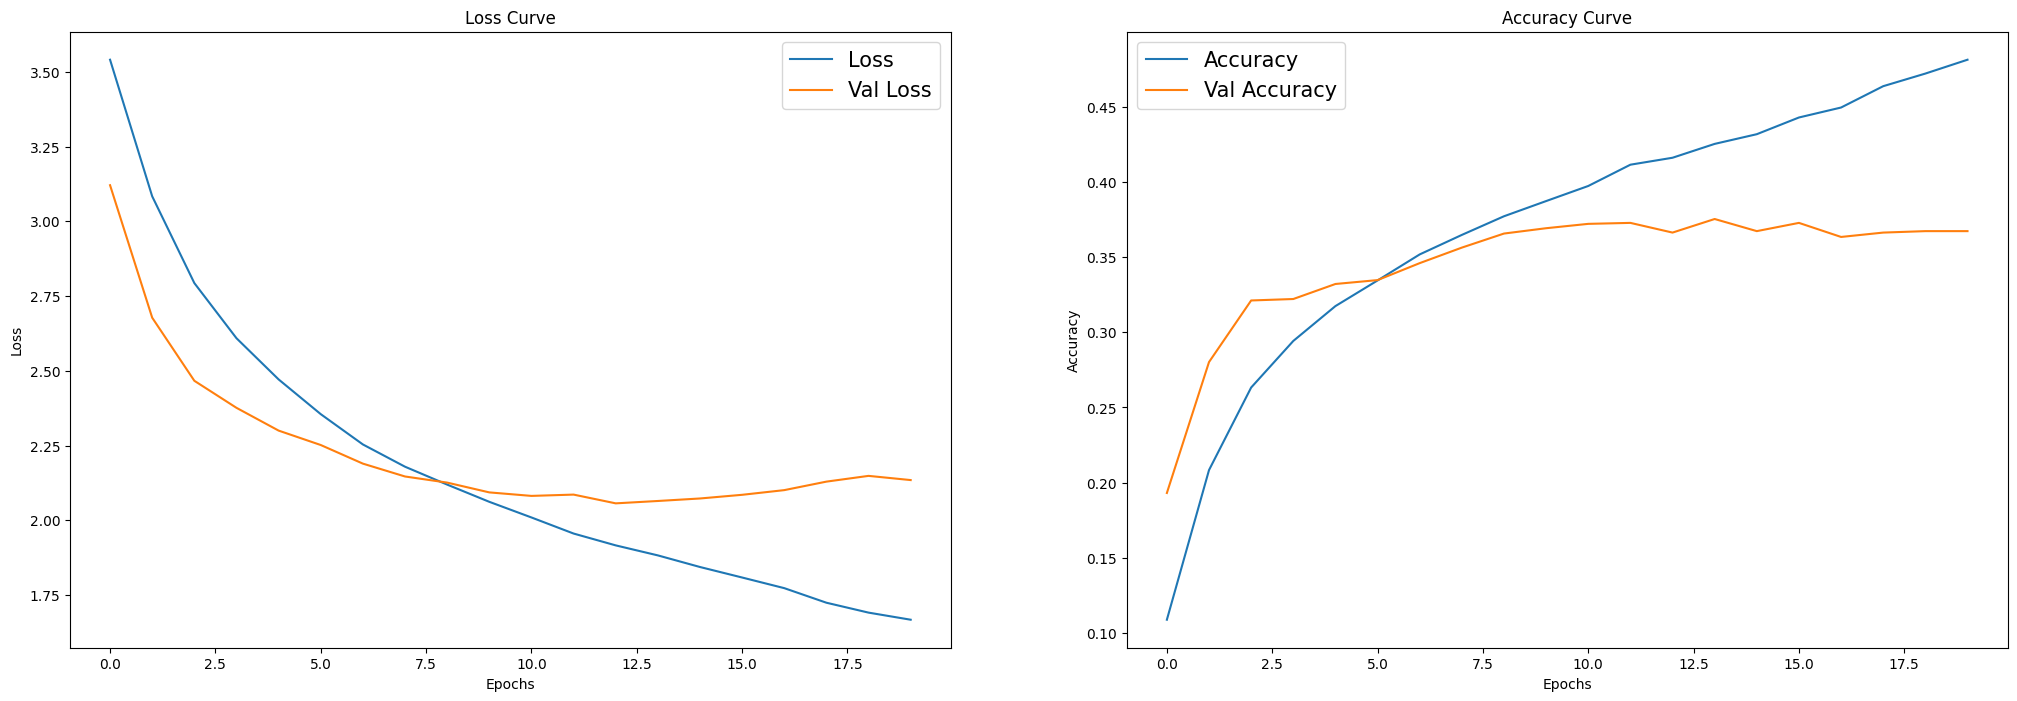

In [274]:
plot_graph(history=history)

In [24]:
model.evaluate(test_data_generator)

14/14 [==============================] - 1s 54ms/step - loss: 2.1605 - accuracy: 0.3557


[2.160508632659912, 0.35567158460617065]